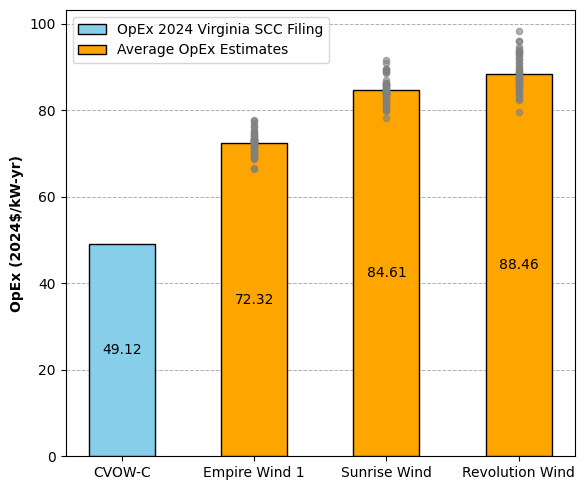

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV files
empire = pd.read_csv("empire_wind_1_opex_results_2024_USD.csv")
sunrise = pd.read_csv("sunrise_wind_opex_results_2024_USD.csv")
revolution = pd.read_csv("revolution_wind_opex_results_2024_USD.csv")

# Reorder data to place CVOW-C first
averages = [
    49.116,  # CVOW-C
    empire["Value"].mean(),
    sunrise["Value"].mean(),
    revolution["Value"].mean()
]

# Labels
projects = ["CVOW-C", "Empire Wind 1", "Sunrise Wind", "Revolution Wind"]

# Colors and legend labels
colors = ["skyblue", "orange", "orange", "orange"]
labels = ["OpEx 2024 Virginia SCC Filing", "Average OpEx Estimates", None, None]

# Create the plot
fig, ax = plt.subplots(figsize=(6, 5))

# Draw grid lines behind the bars
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, zorder=0)

bar_positions = list(range(len(averages)))

bars = []
for pos, avg, color, label in zip(bar_positions, averages, colors, labels):
    bar = ax.bar(
        pos,
        avg,
        color=color,
        edgecolor="black",
        width=0.5,
        label=label,
        zorder=3  # Bars above grid
    )
    bars.append(bar)

# Scatter individual project data (adjusted for CVOW-C first)
ax.scatter([1]*len(empire), empire["Value"], color="grey", alpha=0.6, s=20, zorder=100)
ax.scatter([2]*len(sunrise), sunrise["Value"], color="grey", alpha=0.6, s=20, zorder=100)
ax.scatter([3]*len(revolution), revolution["Value"], color="grey", alpha=0.6, s=20, zorder=100)

# Axis and labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(projects)
ax.set_ylabel("OpEx (2024$/kW-yr)", fontweight='bold')
ax.legend()

# Annotate bars with average values
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            zorder=4
        )

plt.tight_layout()
plt.savefig("opex_comparison.svg", format='svg')
plt.show()
